# 01b - Compare Scenarios: Legacy vs Optimized (Synthetic CLD)

## Goal
Compare two synthetic CLD scenarios generated by the same simulator.

- **Legacy**: random integration / higher variability
- **Optimized**: targeted integration-like platform / lower variability

We compare:
1) Dataset sanity checks (row counts)
2) Stability drop distribution
3) Late-stage titer distribution (late window)
4) Trade-off (Pareto-like) cloud: late titer vs stability drop
5) Bottom-right candidate rate: "high titer + low drop" frequency

This notebook is designed as a shareable report for scenario comparison.

In [11]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DB_LEGACY = "../data/synthetic/raw/cld_2000clones_legacy.db"
DB_OPT = "../data/synthetic/raw/cld_2000clones_optimized.db"

DBS = {
    "legacy": DB_LEGACY,
    "optimized": DB_OPT,
}

print(DBS)

{'legacy': '../data/synthetic/raw/cld_2000clones_legacy.db', 'optimized': '../data/synthetic/raw/cld_2000clones_optimized.db'}


In [12]:
## Define functions to load data from the databases

TABLES = ["clone","passage","assay_result","stability_test","process_condition"]

def row_counts(db_path):
    conn = sqlite3.connect(db_path)
    out = {}
    for t in TABLES:
        out[t] = pd.read_sql_query(f"SELECT COUNT(*) AS n FROM {t}", conn)["n"][0]
    conn.close()
    return out

def assay_type_counts(db_path):
    conn = sqlite3.connect(db_path)
    df = pd.read_sql_query("""
        SELECT assay_type, COUNT(*) AS n
        FROM assay_result
        GROUP BY assay_type
        ORDER BY n DESC
    """, conn)
    conn.close()
    return df

def load_stability(db_path):
    conn = sqlite3.connect(db_path)
    stb = pd.read_sql_query("""
        SELECT clone_id, productivity_drop_pct
        FROM stability_test
    """, conn)
    conn.close()
    return stb

def load_late_mean(db_path, late_start=24, late_end=30):
    """
    Compute late-stage mean titer & aggregation per clone.
    """
    conn = sqlite3.connect(db_path)
    df = pd.read_sql_query("""
        SELECT
            p.clone_id,
            AVG(CASE WHEN ar.assay_type='titer' THEN ar.value END) AS late_mean_titer,
            AVG(CASE WHEN ar.assay_type='aggregation' THEN ar.value END) AS late_mean_aggregation
        FROM assay_result ar
        JOIN passage p ON p.passage_id = ar.passage_id
        WHERE p.passage_number BETWEEN ? AND ?
        GROUP BY p.clone_id
    """, conn, params=[late_start, late_end])
    conn.close()
    return df

In [13]:
## Sanity check: count rows in each table for both databases

counts_rows = []
for name, path in DBS.items():
    c = row_counts(path)
    c["scenario"] = name
    counts_rows.append(c)

counts_df = pd.DataFrame(counts_rows).set_index("scenario")
counts_df

,clone,passage,assay_result,stability_test,process_condition
scenario,,,,,
legacy,2000,60000,242000,2000,60000
optimized,2000,60000,242000,2000,60000


In [14]:
## Sanity check: count assay types in both databases

for name, path in DBS.items():
    print("\n===", name, "===")
    display(assay_type_counts(path))


=== legacy ===


,assay_type,n
0,aggregation,60000
1,titer,60000
2,vcd,60000
3,viability,60000
4,ddpcr_cn,2000



=== optimized ===


,assay_type,n
0,aggregation,60000
1,titer,60000
2,vcd,60000
3,viability,60000
4,ddpcr_cn,2000


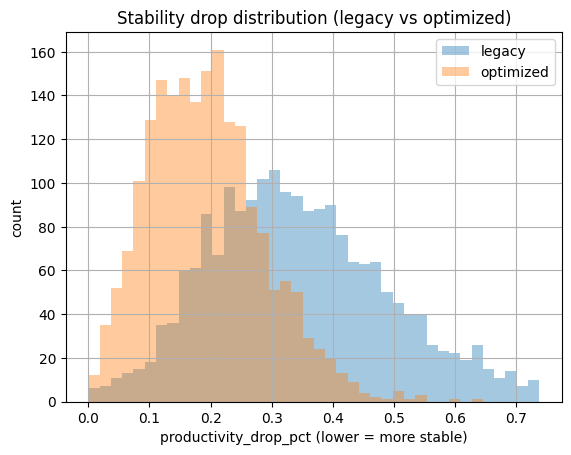

In [15]:
## Stability drop distribution

stb_all = []
for name, path in DBS.items():
    s = load_stability(path).copy()
    s["scenario"] = name
    stb_all.append(s)

stb_all = pd.concat(stb_all, ignore_index=True)

vals = stb_all["productivity_drop_pct"].dropna()
q01, q99 = vals.quantile([0.01, 0.99])
xmin = max(0.0, q01 - 0.05*(q99-q01))
xmax = min(1.0, q99 + 0.05*(q99-q01))

plt.figure()
for name in DBS.keys():
    d = stb_all[stb_all["scenario"] == name]["productivity_drop_pct"].dropna()
    plt.hist(d, bins=40, range=(xmin, xmax), alpha=0.4, label=name)

plt.title("Stability drop distribution (legacy vs optimized)")
plt.xlabel("productivity_drop_pct (lower = more stable)")
plt.ylabel("count")
plt.grid(True)
plt.legend()
plt.show()

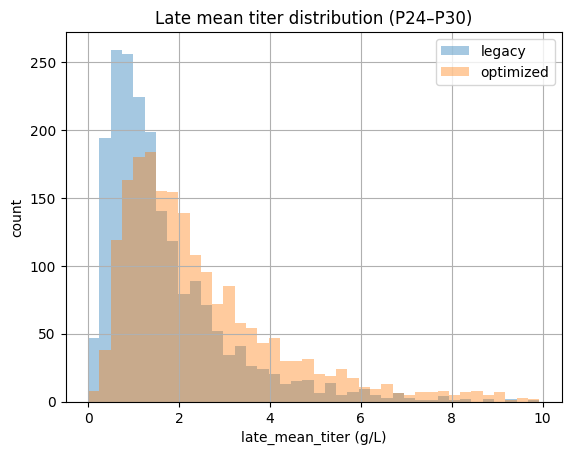

In [16]:
## Late stage titer distribution

LATE_START, LATE_END = 24, 30

late_all = []
for name, path in DBS.items():
    df = load_late_mean(path, LATE_START, LATE_END)
    df["scenario"] = name
    late_all.append(df)

late_all = pd.concat(late_all, ignore_index=True)

vals = late_all["late_mean_titer"].dropna()
q01, q99 = vals.quantile([0.01, 0.99])
xmin = max(0.0, q01 - 0.05*(q99-q01))
xmax = q99 + 0.05*(q99-q01)

plt.figure()
for name in DBS.keys():
    d = late_all[late_all["scenario"] == name]["late_mean_titer"].dropna()
    plt.hist(d, bins=40, range=(xmin, xmax), alpha=0.4, label=name)

plt.title(f"Late mean titer distribution (P{LATE_START}–P{LATE_END})")
plt.xlabel("late_mean_titer (g/L)")
plt.ylabel("count")
plt.grid(True)
plt.legend()
plt.show()

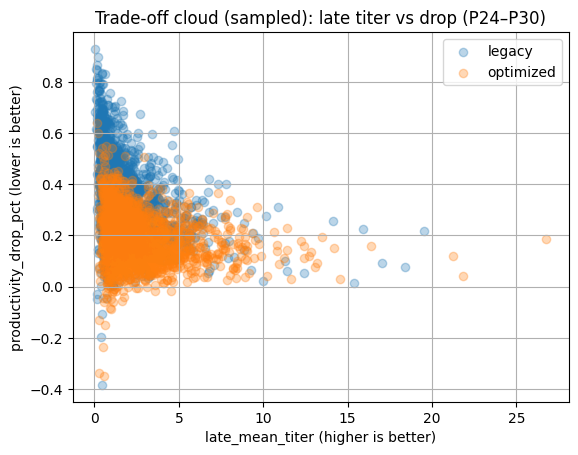

In [17]:
## Trade-off cloud: late titer vs stability drop

def tradeoff_cloud(db_path, late_start=24, late_end=30, sample_n=2000, seed=42):
    stb = load_stability(db_path)
    late = load_late_mean(db_path, late_start, late_end)
    m = stb.merge(late, on="clone_id", how="inner").dropna()

    if len(m) > sample_n:
        m = m.sample(sample_n, random_state=seed)
    return m

plt.figure()
for name, path in DBS.items():
    m = tradeoff_cloud(path, LATE_START, LATE_END, sample_n=2000)
    plt.scatter(m["late_mean_titer"], m["productivity_drop_pct"], alpha=0.3, label=name)

plt.title(f"Trade-off cloud (sampled): late titer vs drop (P{LATE_START}–P{LATE_END})")
plt.xlabel("late_mean_titer (higher is better)")
plt.ylabel("productivity_drop_pct (lower is better)")
plt.grid(True)
plt.legend()
plt.show()

In [18]:
## Bottom-right rate (higher titer + lower drop frequency)

def bottom_right_rate(db_path, late_start=24, late_end=30, titer_q=0.90, drop_q=0.10):
    """
    Bottom-right candidates are clones that are simultaneously:
    - late_mean_titer >= Q(titer_q)
    - productivity_drop_pct <= Q(drop_q)
    """
    stb = load_stability(db_path)
    late = load_late_mean(db_path, late_start, late_end)
    m = stb.merge(late, on="clone_id", how="inner").dropna()

    t_thr = m["late_mean_titer"].quantile(titer_q)
    d_thr = m["productivity_drop_pct"].quantile(drop_q)

    br = (m["late_mean_titer"] >= t_thr) & (m["productivity_drop_pct"] <= d_thr)
    return br.mean(), t_thr, d_thr, len(m)

for name, path in DBS.items():
    rate, t_thr, d_thr, n = bottom_right_rate(path, LATE_START, LATE_END)
    print(f"{name}:")
    print(f"  bottom-right rate = {rate:.4f} (n={n})")
    print(f"  threshold: titer >= Q90 = {t_thr:.3f}, drop <= Q10 = {d_thr:.3f}")

legacy:
  bottom-right rate = 0.0165 (n=2000)
  threshold: titer >= Q90 = 3.430, drop <= Q10 = 0.162
optimized:
  bottom-right rate = 0.0125 (n=2000)
  threshold: titer >= Q90 = 5.031, drop <= Q10 = 0.074


Will save to: ../reports/scenario_report_legacy_vs_optimized_P24-30.png


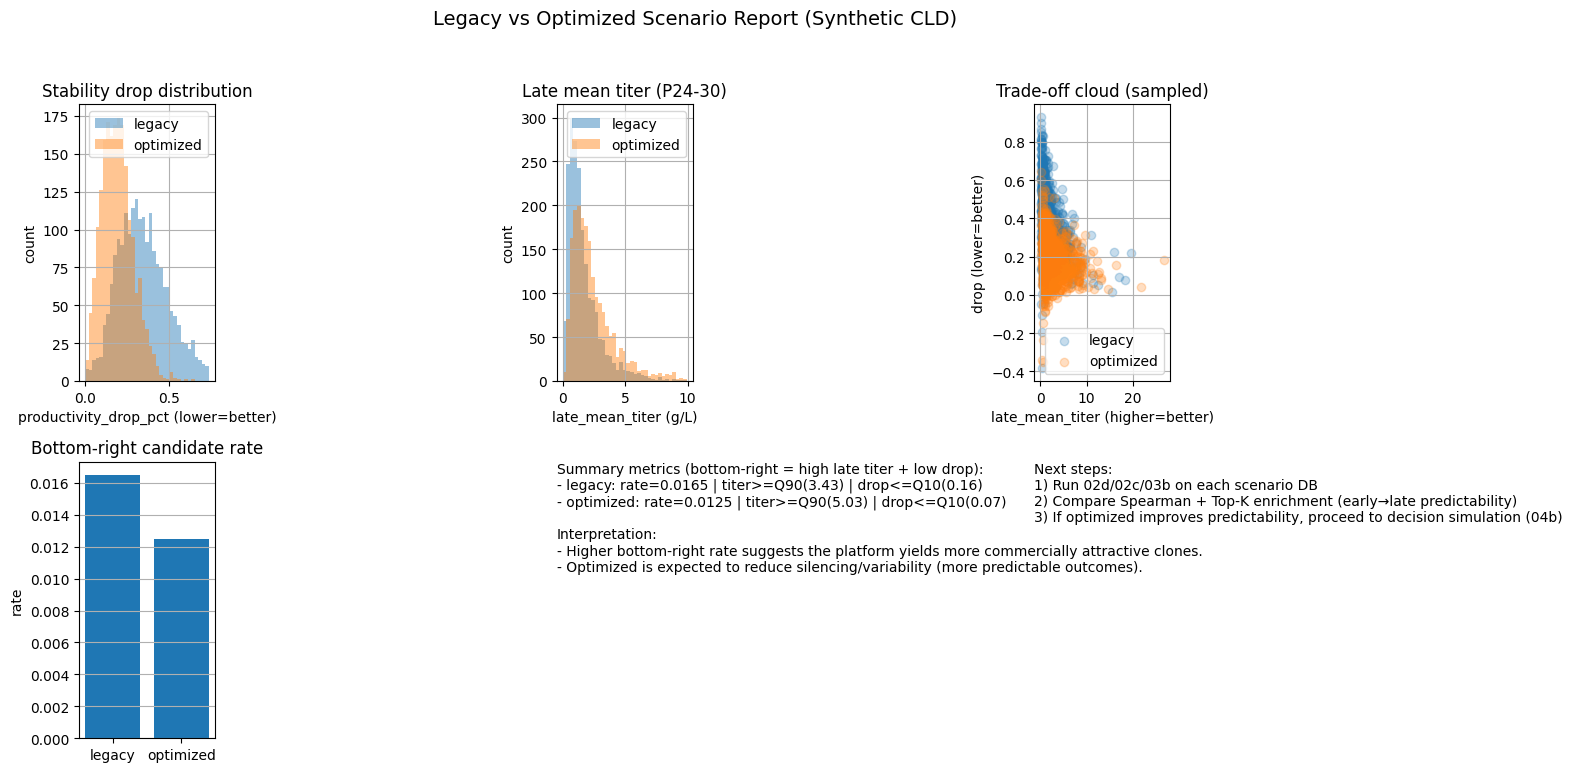

Saved report: ../reports/scenario_report_legacy_vs_optimized_P24-30.png


In [19]:
from pathlib import Path
import matplotlib.pyplot as plt

REPORT_DIR = Path("../reports")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

REPORT_NAME = REPORT_DIR / f"scenario_report_legacy_vs_optimized_P{LATE_START}-{LATE_END}.png"
print("Will save to:", REPORT_NAME)

# 1) Load data (reuse already-loaded frames if available)
# If you already have stb_all and late_all, you can reuse them.
# We'll re-load quickly to make this cell standalone.

stb_all = []
late_all = []
for name, path in DBS.items():
    s = load_stability(path).copy()
    s["scenario"] = name
    stb_all.append(s)

    l = load_late_mean(path, LATE_START, LATE_END).copy()
    l["scenario"] = name
    late_all.append(l)

stb_all = pd.concat(stb_all, ignore_index=True)
late_all = pd.concat(late_all, ignore_index=True)

# 2) Compute bottom-right rates
rows = []
for name, path in DBS.items():
    rate, t_thr, d_thr, n = bottom_right_rate(path, LATE_START, LATE_END)
    rows.append({
        "scenario": name,
        "bottom_right_rate": rate,
        "titer_Q90_threshold": t_thr,
        "drop_Q10_threshold": d_thr,
        "n_clones": n
    })
br_df = pd.DataFrame(rows).set_index("scenario")

# 3) Plot ranges (stable axes)
drop_vals = stb_all["productivity_drop_pct"].dropna()
d01, d99 = drop_vals.quantile([0.01, 0.99])
drop_xmin = max(0.0, d01 - 0.05*(d99-d01))
drop_xmax = min(1.0, d99 + 0.05*(d99-d01))

titer_vals = late_all["late_mean_titer"].dropna()
t01, t99 = titer_vals.quantile([0.01, 0.99])
titer_xmin = max(0.0, t01 - 0.05*(t99-t01))
titer_xmax = t99 + 0.05*(t99-t01)

# 4) Build a 1-page figure (no explicit colors)
fig = plt.figure(figsize=(14, 8))

# ---- Panel A: Stability drop histogram
ax1 = fig.add_subplot(2, 3, 1)
for name in DBS.keys():
    d = stb_all[stb_all["scenario"] == name]["productivity_drop_pct"].dropna()
    ax1.hist(d, bins=35, range=(drop_xmin, drop_xmax), alpha=0.45, label=name)
ax1.set_title("Stability drop distribution")
ax1.set_xlabel("productivity_drop_pct (lower=better)")
ax1.set_ylabel("count")
ax1.grid(True)
ax1.legend()

# ---- Panel B: Late titer histogram
ax2 = fig.add_subplot(2, 3, 2)
for name in DBS.keys():
    d = late_all[late_all["scenario"] == name]["late_mean_titer"].dropna()
    ax2.hist(d, bins=35, range=(titer_xmin, titer_xmax), alpha=0.45, label=name)
ax2.set_title(f"Late mean titer (P{LATE_START}-{LATE_END})")
ax2.set_xlabel("late_mean_titer (g/L)")
ax2.set_ylabel("count")
ax2.grid(True)
ax2.legend()

# ---- Panel C: Trade-off scatter (sampled)
ax3 = fig.add_subplot(2, 3, 3)
for name, path in DBS.items():
    m = tradeoff_cloud(path, LATE_START, LATE_END, sample_n=1500)
    ax3.scatter(m["late_mean_titer"], m["productivity_drop_pct"], alpha=0.25, label=name)
ax3.set_title("Trade-off cloud (sampled)")
ax3.set_xlabel("late_mean_titer (higher=better)")
ax3.set_ylabel("drop (lower=better)")
ax3.grid(True)
ax3.legend()

# ---- Panel D: Bottom-right rate bar
ax4 = fig.add_subplot(2, 3, 4)
ax4.bar(br_df.index.tolist(), br_df["bottom_right_rate"].values)
ax4.set_title("Bottom-right candidate rate")
ax4.set_ylabel("rate")
ax4.grid(True, axis="y")

# ---- Panel E: Text summary
ax5 = fig.add_subplot(2, 3, 5)
ax5.axis("off")
lines = []
lines.append("Summary metrics (bottom-right = high late titer + low drop):")
for scenario in br_df.index:
    r = br_df.loc[scenario, "bottom_right_rate"]
    t_thr = br_df.loc[scenario, "titer_Q90_threshold"]
    d_thr = br_df.loc[scenario, "drop_Q10_threshold"]
    lines.append(f"- {scenario}: rate={r:.4f} | titer>=Q90({t_thr:.2f}) | drop<=Q10({d_thr:.2f})")
lines.append("")
lines.append("Interpretation:")
lines.append("- Higher bottom-right rate suggests the platform yields more commercially attractive clones.")
lines.append("- Optimized is expected to reduce silencing/variability (more predictable outcomes).")
ax5.text(0.0, 1.0, "\n".join(lines), va="top", fontsize=10)

# ---- Panel F: Notes / next steps
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis("off")
notes = []
notes.append("Next steps:")
notes.append("1) Run 02d/02c/03b on each scenario DB")
notes.append("2) Compare Spearman + Top-K enrichment (early→late predictability)")
notes.append("3) If optimized improves predictability, proceed to decision simulation (04b)")
ax6.text(0.0, 1.0, "\n".join(notes), va="top", fontsize=10)

fig.suptitle("Legacy vs Optimized Scenario Report (Synthetic CLD)", fontsize=14)
fig.tight_layout(rect=[0, 0.02, 1, 0.95])

fig.savefig(REPORT_NAME, dpi=200)
plt.show()

print("Saved report:", REPORT_NAME)

## How to interpret results

- If **optimized** shows lower drop and/or higher bottom-right rate, the platform scenario effectively improves late-stage stability while preserving productivity.
- If **legacy** has a heavier high-titer tail but worse stability, it reflects the "jackpot vs reliability" trade-off.
- The key metric for early decision system is often not mean performance but:
    - "bottom-right candidate frequency"
    - ranking stability (Top-K enrichment in later notebooks)

In [20]:
import pandas as pd

df = pd.read_csv("../data/synthetic/raw/clone_latent_truths_2000_legacy.csv")

print("super rate:", df["is_super"].mean())
print("aggressive rate:", df["is_aggressive"].mean())

print(df.groupby("is_super")[["productivity","stability","k_decay_i"]].mean())
print(df.groupby("is_aggressive")[["productivity","stability","k_decay_i"]].mean())

super rate: 0.006
aggressive rate: 0.0285
          productivity  stability  k_decay_i
is_super                                    
0            94.618526   0.615414   0.053762
1           281.948988   0.838398   0.024101
               productivity  stability  k_decay_i
is_aggressive                                    
0                 93.742413   0.618673   0.053464
1                163.921203   0.551254   0.057670


In [21]:
import pandas as pd
import sqlite3

# paths (adjust if needed)
DB_LEGACY = "../data/synthetic/raw/cld_2000clones_legacy.db"
LATENT_LEGACY = "../data/synthetic/raw/clone_latent_truths_2000_legacy.csv"

LATE_START, LATE_END = 24, 30

# load latents (contains is_super / is_aggressive)
lat = pd.read_csv(LATENT_LEGACY)[["clone_id","is_super","is_aggressive"]]

# compute late outcomes from DB
conn = sqlite3.connect(DB_LEGACY)
late = pd.read_sql_query("""
    SELECT p.clone_id,
           AVG(CASE WHEN ar.assay_type='titer' THEN ar.value END) AS late_mean_titer,
           AVG(CASE WHEN ar.assay_type='aggregation' THEN ar.value END) AS late_mean_aggregation
    FROM assay_result ar
    JOIN passage p ON p.passage_id = ar.passage_id
    WHERE p.passage_number BETWEEN ? AND ?
    GROUP BY p.clone_id
""", conn, params=[LATE_START, LATE_END])

stb = pd.read_sql_query("""
    SELECT clone_id, productivity_drop_pct
    FROM stability_test
""", conn)
conn.close()

df = lat.merge(late, on="clone_id").merge(stb, on="clone_id")

# define groups
def group_name(r):
    if r["is_super"] == 1:
        return "super"
    if r["is_aggressive"] == 1:
        return "aggressive"
    return "standard"

df["group"] = df.apply(group_name, axis=1)

# bottom-right definition
t_thr = df["late_mean_titer"].quantile(0.90)
d_thr = df["productivity_drop_pct"].quantile(0.10)
df["bottom_right"] = (df["late_mean_titer"] >= t_thr) & (df["productivity_drop_pct"] <= d_thr)

# summary table
summary = df.groupby("group").agg(
    n=("clone_id","count"),
    mean_late_titer=("late_mean_titer","mean"),
    mean_drop=("productivity_drop_pct","mean"),
    bottom_right_rate=("bottom_right","mean"),
).sort_values("bottom_right_rate", ascending=False)

summary

,n,mean_late_titer,mean_drop,bottom_right_rate
group,,,,
super,12,7.753461,0.074226,0.500000
aggressive,57,2.620086,0.408161,0.017544
standard,1931,1.671773,0.346504,0.013465
